# 5. Group Visuals
The goal of this notebook is to generate visuals involving the results of the three different severity class systems that are part of the analysis. This should be run after heterogeneity metrics are computed. 

In [1]:
library(tidyverse)
library(ggplot2)
library(rstan)
library(Hmisc)
library(forestplot)
library(readxl)
theme_set(theme_bw())

Warning message:
"package 'tidyverse' was built under R version 4.3.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: StanHeaders


rstan version 2.32.5 (Stan version 2.32.2)


For execution on a local, multicore CPU with excess RAM we recommend calling
options(mc.cores = parallel::detectCores()).
To avoid recompilation of unchanged Stan programs, we recommend calling
rstan_options(auto_write = TRUE)
For within-chain threading using `reduce_sum()` or `map_rect()` Stan functions,
change `threa

## Data Input

In [2]:
inv_logit = plogis
logit = qlogis

save_plot = function(curr_plot, filepath, width, height, units, res, type = "png"){
    if(type == "png"){
        png(filepath, width = width, height = height, units = units, res = res)
    }else if(type == "eps"){
        #Defaults to inches as units
        postscript(filepath, width = width, height = height)
    }else{
        pdf(filepath, width = width, height = height)
    }
    print(curr_plot)
    dev.off()
}

save_plot_all_formats = function(curr_plot, dir_path, filename, width, height, units, res){
    png_path = file.path(dir_path, "png", paste0(filename, ".png"))
    eps_path = file.path(dir_path, "eps", paste0(filename, ".eps"))
    pdf_path = file.path(dir_path, "pdf", paste0(filename, ".pdf"))

    save_plot(curr_plot, png_path, width, height, units, res, type = "png")
    save_plot(curr_plot, eps_path, width, height, units, res, type = "eps")
    save_plot(curr_plot, pdf_path, width, height, units, res, type = "pdf")
}

save_output = TRUE

In [3]:
base_dir = getwd()
setwd("..")
index_dir = getwd() #Where the review index is in
setwd(base_dir)

io_set = "Main Results"

model_input_dir = file.path(base_dir, "Processed Data", io_set)
model_output_dir = file.path(base_dir, "Model Output", io_set)

In [4]:
sev_class_types = c("1997type", "2009type", "hospitalisation")

het_dir = file.path(base_dir, "Heterogeneity Estimates", io_set)
visuals_output_dir = file.path(base_dir, "Visuals Output", io_set, "Group Visuals")


model_input_paths = file.path(model_input_dir, paste0("data_", sev_class_types, ".rds"))
model_output_paths = file.path(model_output_dir, paste0("Results_LogisticRegression_mean=0_sd=2_sd_mean=0.5_sdsd=2_", sev_class_types, ".rds"))
het_results_paths = file.path(het_dir, paste0("I2_Estimates_", sev_class_types, ".rds"))

In [5]:
model_inputs = lapply(model_input_paths, readRDS)
model_outputs = lapply(model_output_paths, readRDS)
het_results = lapply(het_results_paths, readRDS)

## Scenario Probability Visuals
Here we prepare our data for visualisation. The first thing we need is to get estimates of the proportion of severe cases per scenario aross the different severity class systems

In [6]:
process_scenario_probs = function(curr_input_data, curr_output_data, curr_sev_class_type, curr_het_results){
    #Probabilities are given in the estimates of p 
    ref_region = curr_input_data$ref_region
    non_ref_region = ifelse(ref_region == "Asia", "Americas", "Asia")
    ref_serotype_exposure = curr_input_data$ref_serotype_exposure
    ref_scenario = curr_input_data$ref_scenario
    non_ref_seroprior = curr_input_data$char_mat_guide %>% filter(CharMatIndex >0) %>% pull(SeroPriorExp) %>% as.character
    
    
    scenario_labels = c(ref_scenario, 
                        paste0(ref_region, "-", non_ref_seroprior),
                        paste0(non_ref_region, "-", c(ref_serotype_exposure, non_ref_seroprior))
                       )
    #Get estimates of p
    p_estimates = summary(curr_output_data, pars = "p")$summary %>% data.frame %>% 
                    select(mean, X2.5., X97.5.) %>% rename(PointEst = mean, Lower = X2.5., Upper = X97.5.) %>% 
                    mutate(Scenario = scenario_labels)

    #Get scenarios and then join the p estimates to them, removing rows where we do not have an estimate
    scenario_df = curr_input_data$scenario_df %>% select(Scenario, Inclusion, NumStudies, Severe, N) %>% 
                    left_join(p_estimates, by = "Scenario") %>% mutate(SevClass = curr_sev_class_type) %>%
                    filter(!is.na(PointEst)) %>% arrange(Scenario) %>% 
                    mutate(DispVal = sprintf("%.2f%% [%.2f to %.2f%%]", 100*PointEst, 100*Lower, 100*Upper)) %>% 
                    left_join(curr_het_results %>% select(Scenario, I2_est), by = "Scenario") %>%
                    mutate(DispHet = ifelse(is.na(I2_est), "-", sprintf("%.2f%%", I2_est * 100))) 
    disp_sev_class = ""
    if(curr_sev_class_type == "1997type"){
        disp_sev_class = "1997-type"
    }else if(curr_sev_class_type == "2009type"){
        disp_sev_class = "2009-type"
    }else{
        disp_sev_class = "Hospitalisation"
    }
    #Create the header row
    header_row = data.frame(Scenario = disp_sev_class, Inclusion = NA,
                           NumStudies = NA, Severe = NA, N = NA, PointEst = NA, 
                            Lower = NA, Upper = NA, DispVal = NA, I2_est = NA, DispHet = NA,
                           SevClass = "HEADER")

    scenario_df = rbind(header_row, scenario_df %>% mutate(Scenario = paste0("       ", Scenario))) 
    return(scenario_df)
}

In [7]:
scenario_probs = mapply(process_scenario_probs, model_inputs, model_outputs, sev_class_types, het_results, SIMPLIFY = FALSE)

In [8]:
merged_scenarios = do.call(rbind, scenario_probs)

In [9]:
merged_forest_df = merged_scenarios
merged_forest_df = merged_forest_df %>% mutate(Pooled = ifelse(Inclusion == "Included", "Pooled", 
                                           ifelse(Inclusion == "Excluded", "Not Pooled", NA))) %>% 
                                        mutate(N = ifelse(Inclusion == "Excluded", "-", N),
                                               Severe = ifelse(Inclusion == "Excluded", "-", Severe))


pdf 
  2

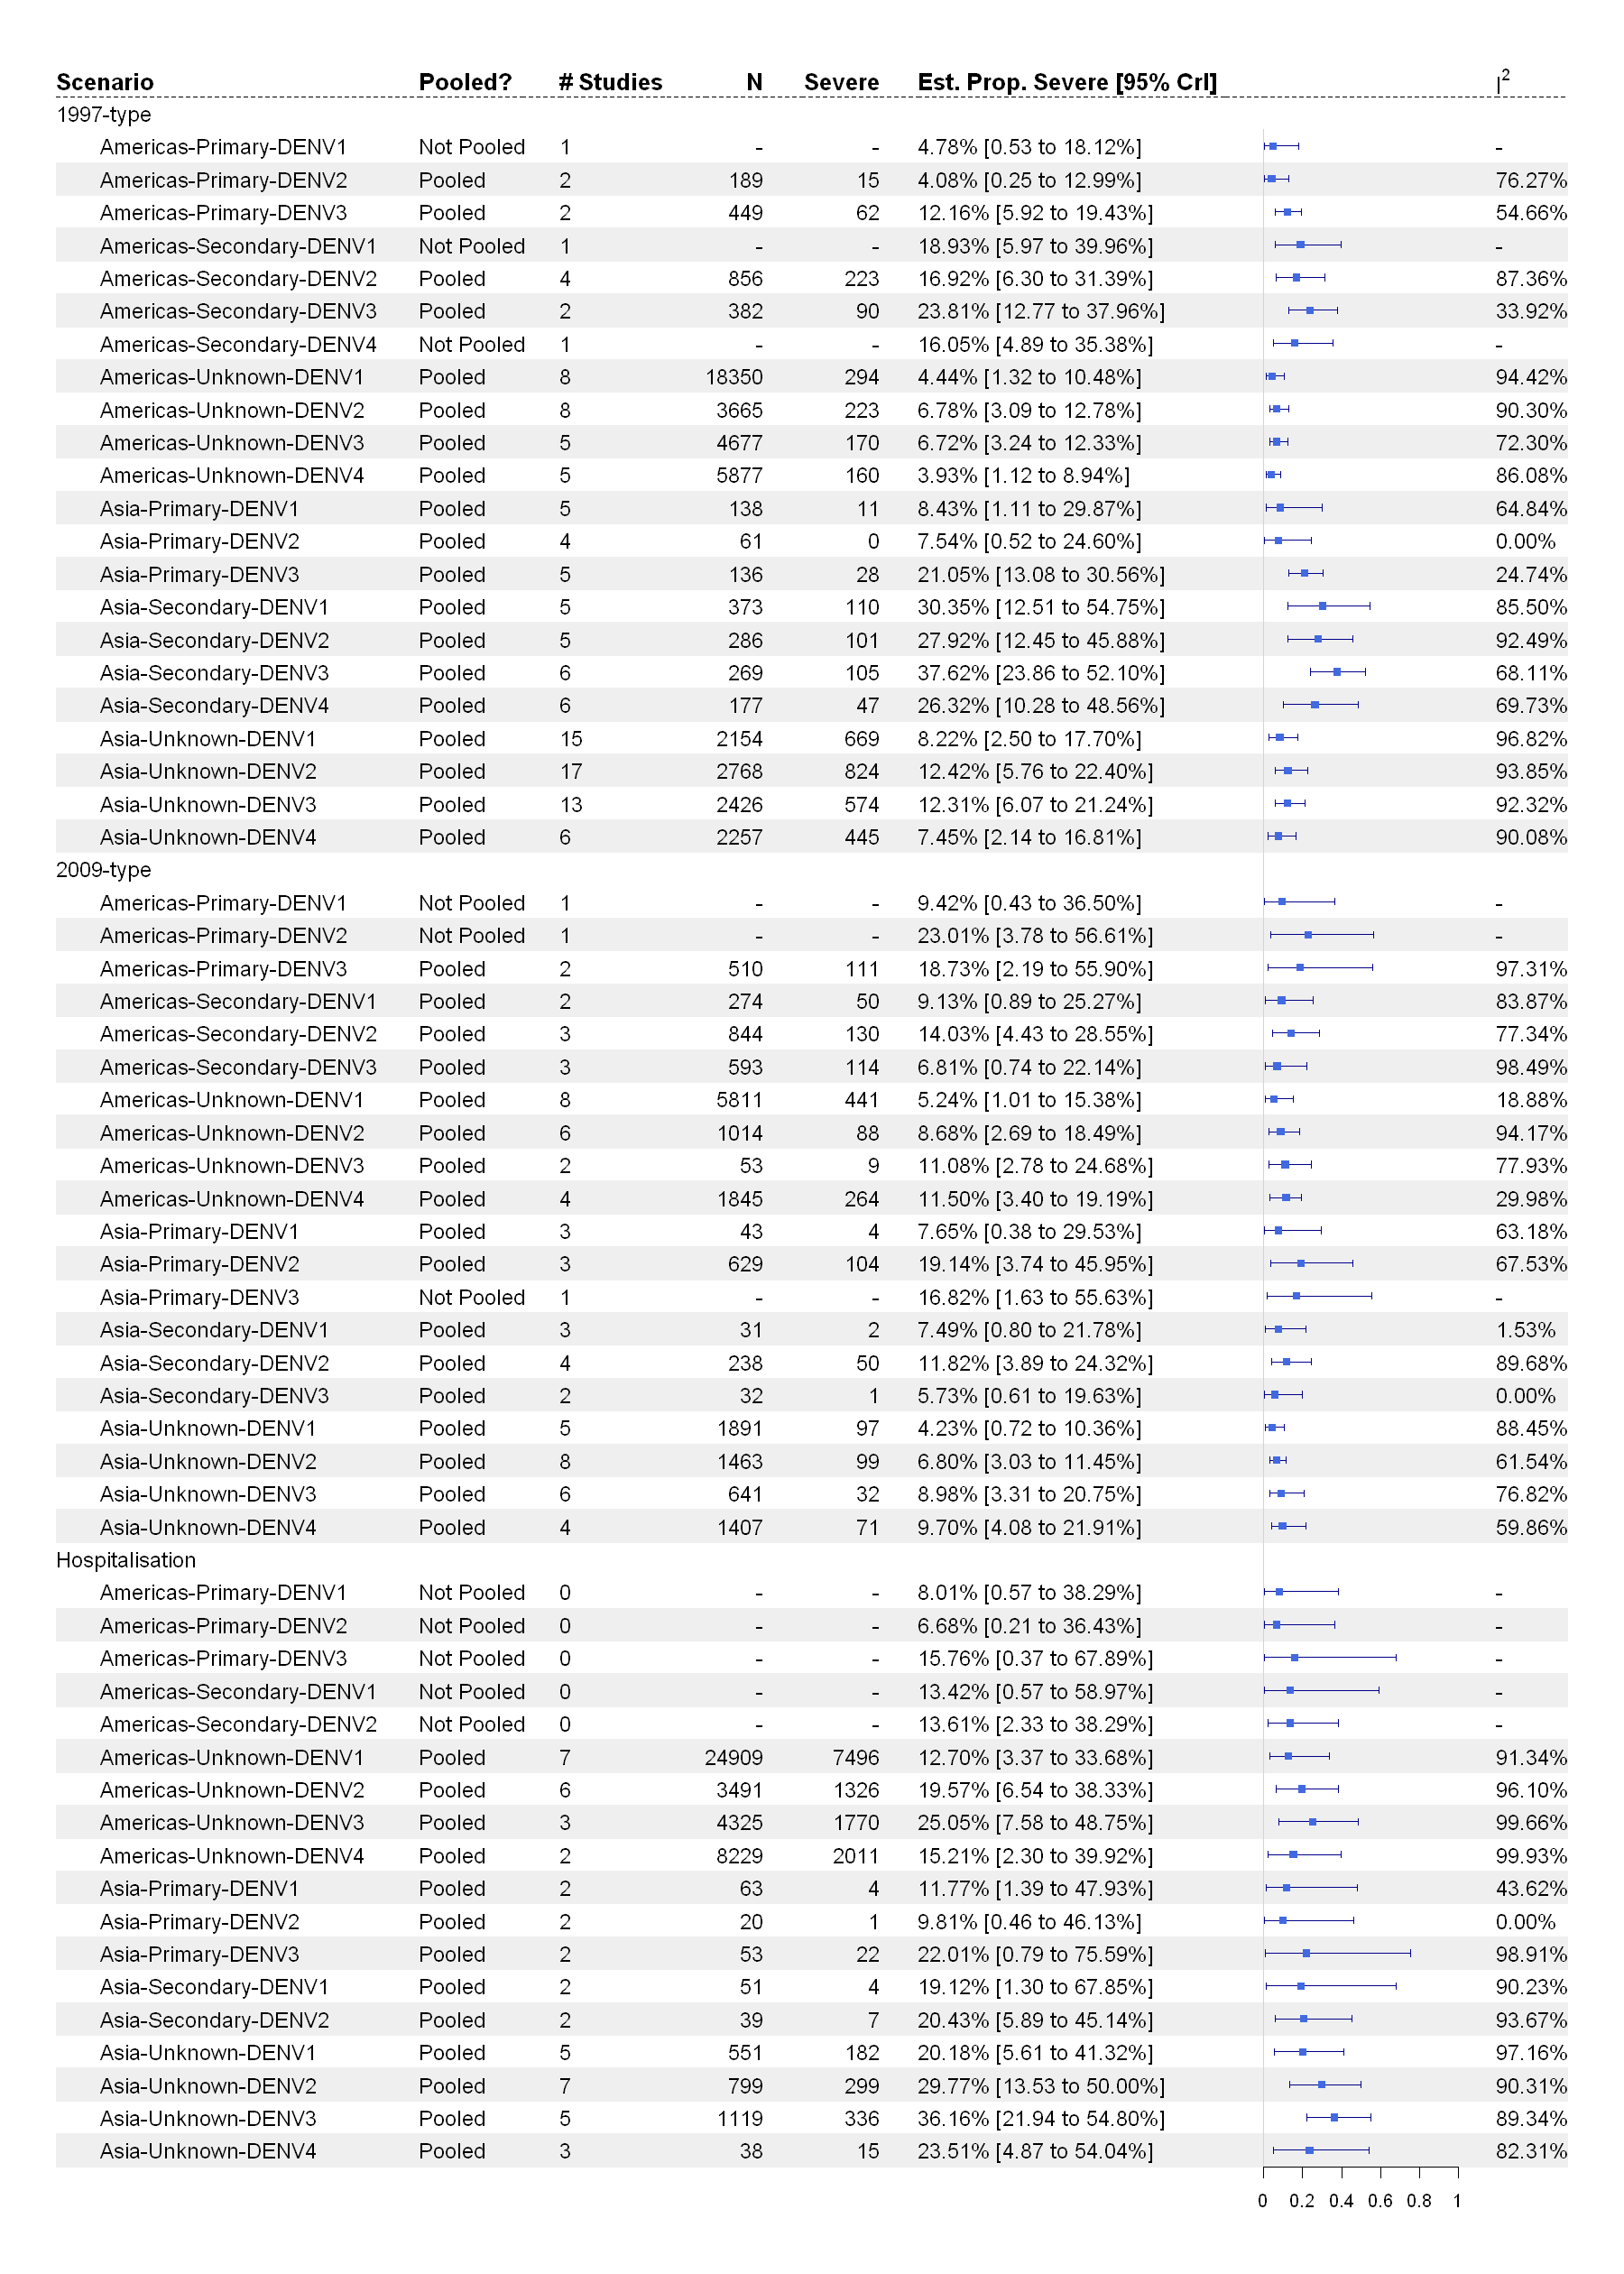

In [10]:
options(repr.plot.width = 15, repr.plot.height = 21)
merged_forest_plot = merged_forest_df %>% 
    forestplot(labeltext = c(Scenario, Pooled, NumStudies, N, Severe, DispVal, DispHet),
                mean = PointEst, lower = Lower, upper = Upper,
                xticks = seq(0, 1, by = 0.2), ci.vertices = TRUE, boxsize = 0.2,
                align = c("l", "l", "l", "r", "r", "l"), graphwidth = unit(1.8, "in"), 
              ) |>
    fp_add_lines(h_2 = gpar(lty = 2)) |>
    fp_set_style(box = "royalblue", line = gpar(col = "darkblue"), summary = "royalblue",
                txt_gp = fpTxtGp(cex =1.2, ticks = gpar(cex = 1))) |>
    fp_add_header(
                    Scenario = "Scenario",
                    Pooled = "Pooled?",
                    NumStudies = "# Studies",
                    N = "N", 
                    Severe = "Severe", 
                    DispVal = "Est. Prop. Severe [95% CrI]",
                    DispHet = expression(I^{2})) |> 
    fp_decorate_graph(graph.pos = 7) |>
    fp_set_zebra_style("#EFEFEF")


if(save_output){
    #save_plot(merged_forest_plot, file.path(visuals_output_dir, paste0("ScenarioForest.png")), 15, 21, "in", 600)
    save_plot_all_formats(merged_forest_plot, visuals_output_dir, "ScenarioForest", 15, 21, "in", 600)
}
merged_forest_plot

## Versus Reference OR Table
Here we generate an odds ratio table versus the reference value. Note that this assumes the same reference class and region across all three severity class systems. These values are stored in the or_beta quantity from the model results.

In [11]:
#We retrieve the reference region and serotype-prior exposure from the first model input
#This assumes that this stays uniform throughout the analysis with the three severity class systems. 
ref_region = model_inputs[[1]]$ref_region
ref_serotype_exposure = model_inputs[[1]]$ref_serotype_exposure
non_ref_region = ifelse(ref_region == "Asia", "Americas", "Asia")

In [12]:
# curr_input_data = model_inputs[[1]]
# curr_output_data = model_outputs[[1]]
# curr_sev_class_type = sev_class_types[[1]]

In [13]:
process_or_vals = function(curr_input_data, curr_output_data, curr_sev_class_type, log = FALSE){
    ref_region = curr_input_data$ref_region
    non_ref_region = ifelse(ref_region == "Asia", "Americas", "Asia")
    ref_serotype_exposure = curr_input_data$ref_serotype_exposure
    ref_scenario = curr_input_data$ref_scenario
    non_ref_seroprior = curr_input_data$char_mat_guide %>% filter(CharMatIndex >0) %>% pull(SeroPriorExp) %>% as.character
    
    or_labels = c("Intercept", non_ref_seroprior, non_ref_region) #Labels for the odds ratios
    
    #Get te odds ratio estimates
    par_name = "or_beta"
    if(log){
        par_name = "log_or_beta"
    }
    or_beta_est = summary(curr_output_data, pars = par_name)$summary %>% data.frame %>% 
                    select(mean, X2.5., X97.5.) %>% 
                    rename(PointEst = mean, Lower = X2.5., Upper = X97.5.) %>% 
                    mutate(Label = or_labels, 
                           SevClass = curr_sev_class_type,
                           DispVal = sprintf("%.2f [%.2f to %.2f]", PointEst, Lower, Upper)) #Add in the label and the severity system
    
    return(or_beta_est)
}

In [14]:
sev_class_ors = mapply(process_or_vals, model_inputs, model_outputs, sev_class_types, SIMPLIFY = FALSE)
log_sev_class_ors = mapply(process_or_vals, model_inputs, model_outputs, sev_class_types, rep(TRUE, 3), SIMPLIFY = FALSE)

In [15]:
options(repr.plot.width = 13, repr.plot.height = 8)
or_vis_df = do.call(rbind, sev_class_ors) %>% 
            mutate(DispVal = ifelse(((Lower > 1) | (Upper < 1) & Label != "Intercept"), paste0("***", DispVal), DispVal)) %>% #Check significance
            select(Label, SevClass, DispVal) %>% 
            pivot_wider(id_cols = Label, names_from = SevClass, values_from = DispVal)

disp_order = expand.grid(c(paste0("DENV", 1:4)), c("Unknown", "Primary", "Secondary")) %>% 
    mutate(Order = paste0(Var2, "-", Var1)) %>% filter(Order != ref_serotype_exposure) %>% pull(Order)
disp_order = c("Intercept", disp_order, non_ref_region)
or_vis_df = or_vis_df %>% mutate(Label = factor(Label, levels = disp_order)) %>% arrange(Label)

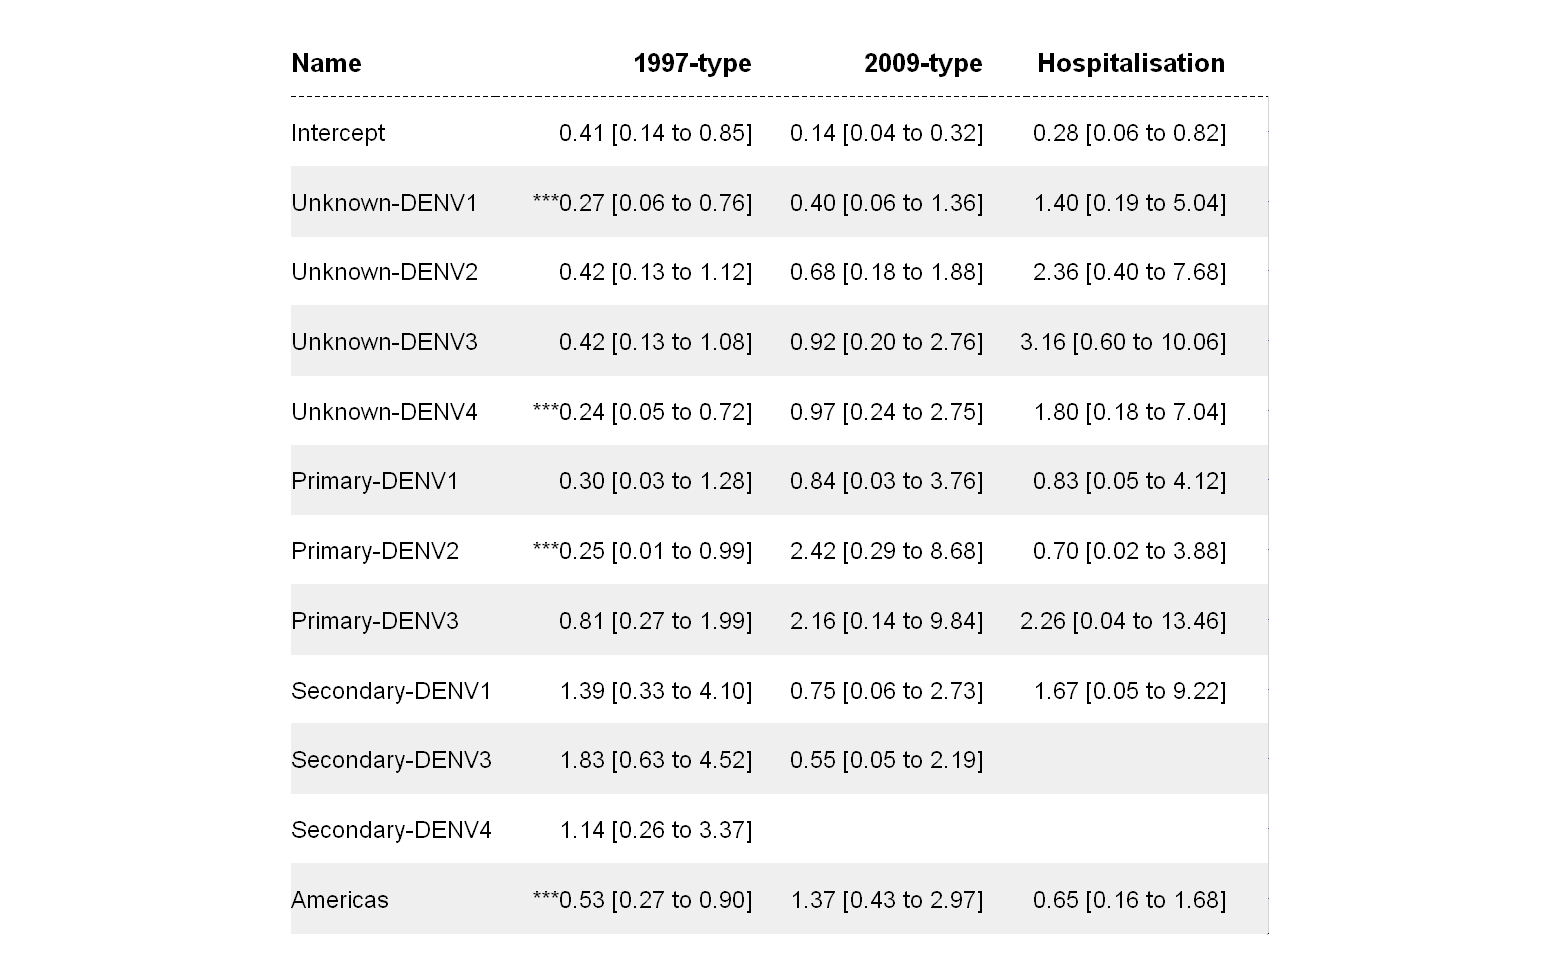

In [16]:
or_vis_df %>% mutate(mean = 0, lower = 0, upper = 0) %>%
    forestplot(labeltext = c(Label, `1997type`, `2009type`, hospitalisation), 
                xticks = seq(0, 1, by = 0.2), ci.vertices = TRUE, boxsize = 0.0,
                align = c("l", "r", "r", "r"),  graphwidth = unit(0, "cm")
              ) |>
    fp_add_lines(h_2 = gpar(lty = 2)) |>
    fp_set_style(box = "royalblue", line = gpar(col = "darkblue"), summary = "royalblue",
                txt_gp = fpTxtGp(cex =1.2, ticks = gpar(cex = 0))) |>
    fp_add_header(
                    Label = "Name",
                    `1997type` = "1997-type",
                    `2009type` = "2009-type",
                    hospitalisation = "Hospitalisation") |> 
    #fp_decorate_graph(graph.pos = 0) |>
    fp_set_zebra_style("#EFEFEF")

In [17]:
or_vis_alt_df = do.call(rbind, sev_class_ors) %>% 
                pivot_wider(id_cols = c(Label), 
                          names_from = SevClass, 
                          values_from = c(PointEst, Lower, Upper, DispVal)) %>%
                mutate(Label = paste0("    ", Label))


log_or_vis_alt_df = do.call(rbind, log_sev_class_ors) %>% 
                pivot_wider(id_cols = c(Label), 
                          names_from = SevClass, 
                          values_from = c(PointEst, Lower, Upper, DispVal))%>%
                mutate(Label = paste0("    ", Label))


ref_seroprior_label = as.data.frame(as.list(rep(NA, ncol(or_vis_alt_df)))) %>% `colnames<-`(colnames(log_or_vis_alt_df)) %>%
                        mutate(Label = "Versus Secondary DENV2")
ref_reg_label = as.data.frame(as.list(rep(NA, ncol(or_vis_alt_df))))%>% `colnames<-`(colnames(log_or_vis_alt_df))%>%
                        mutate(Label = "Versus Asia")

#Insert the reference seroprior label
or_vis_alt_df = rbind(or_vis_alt_df[1, , drop = FALSE], ref_seroprior_label, or_vis_alt_df[-1, , drop = FALSE])
log_or_vis_alt_df = rbind(log_or_vis_alt_df[1, , drop = FALSE], ref_seroprior_label, log_or_vis_alt_df[-1, , drop = FALSE])

#Insert the reference reg label
curr_n = nrow(or_vis_alt_df)
or_vis_alt_df = rbind(or_vis_alt_df[1:(curr_n-1), , drop = FALSE], ref_reg_label, or_vis_alt_df[curr_n, , drop = FALSE])
log_or_vis_alt_df = rbind(log_or_vis_alt_df[1:(curr_n-1), , drop = FALSE], ref_reg_label, log_or_vis_alt_df[curr_n, , drop = FALSE])

pdf 
  2

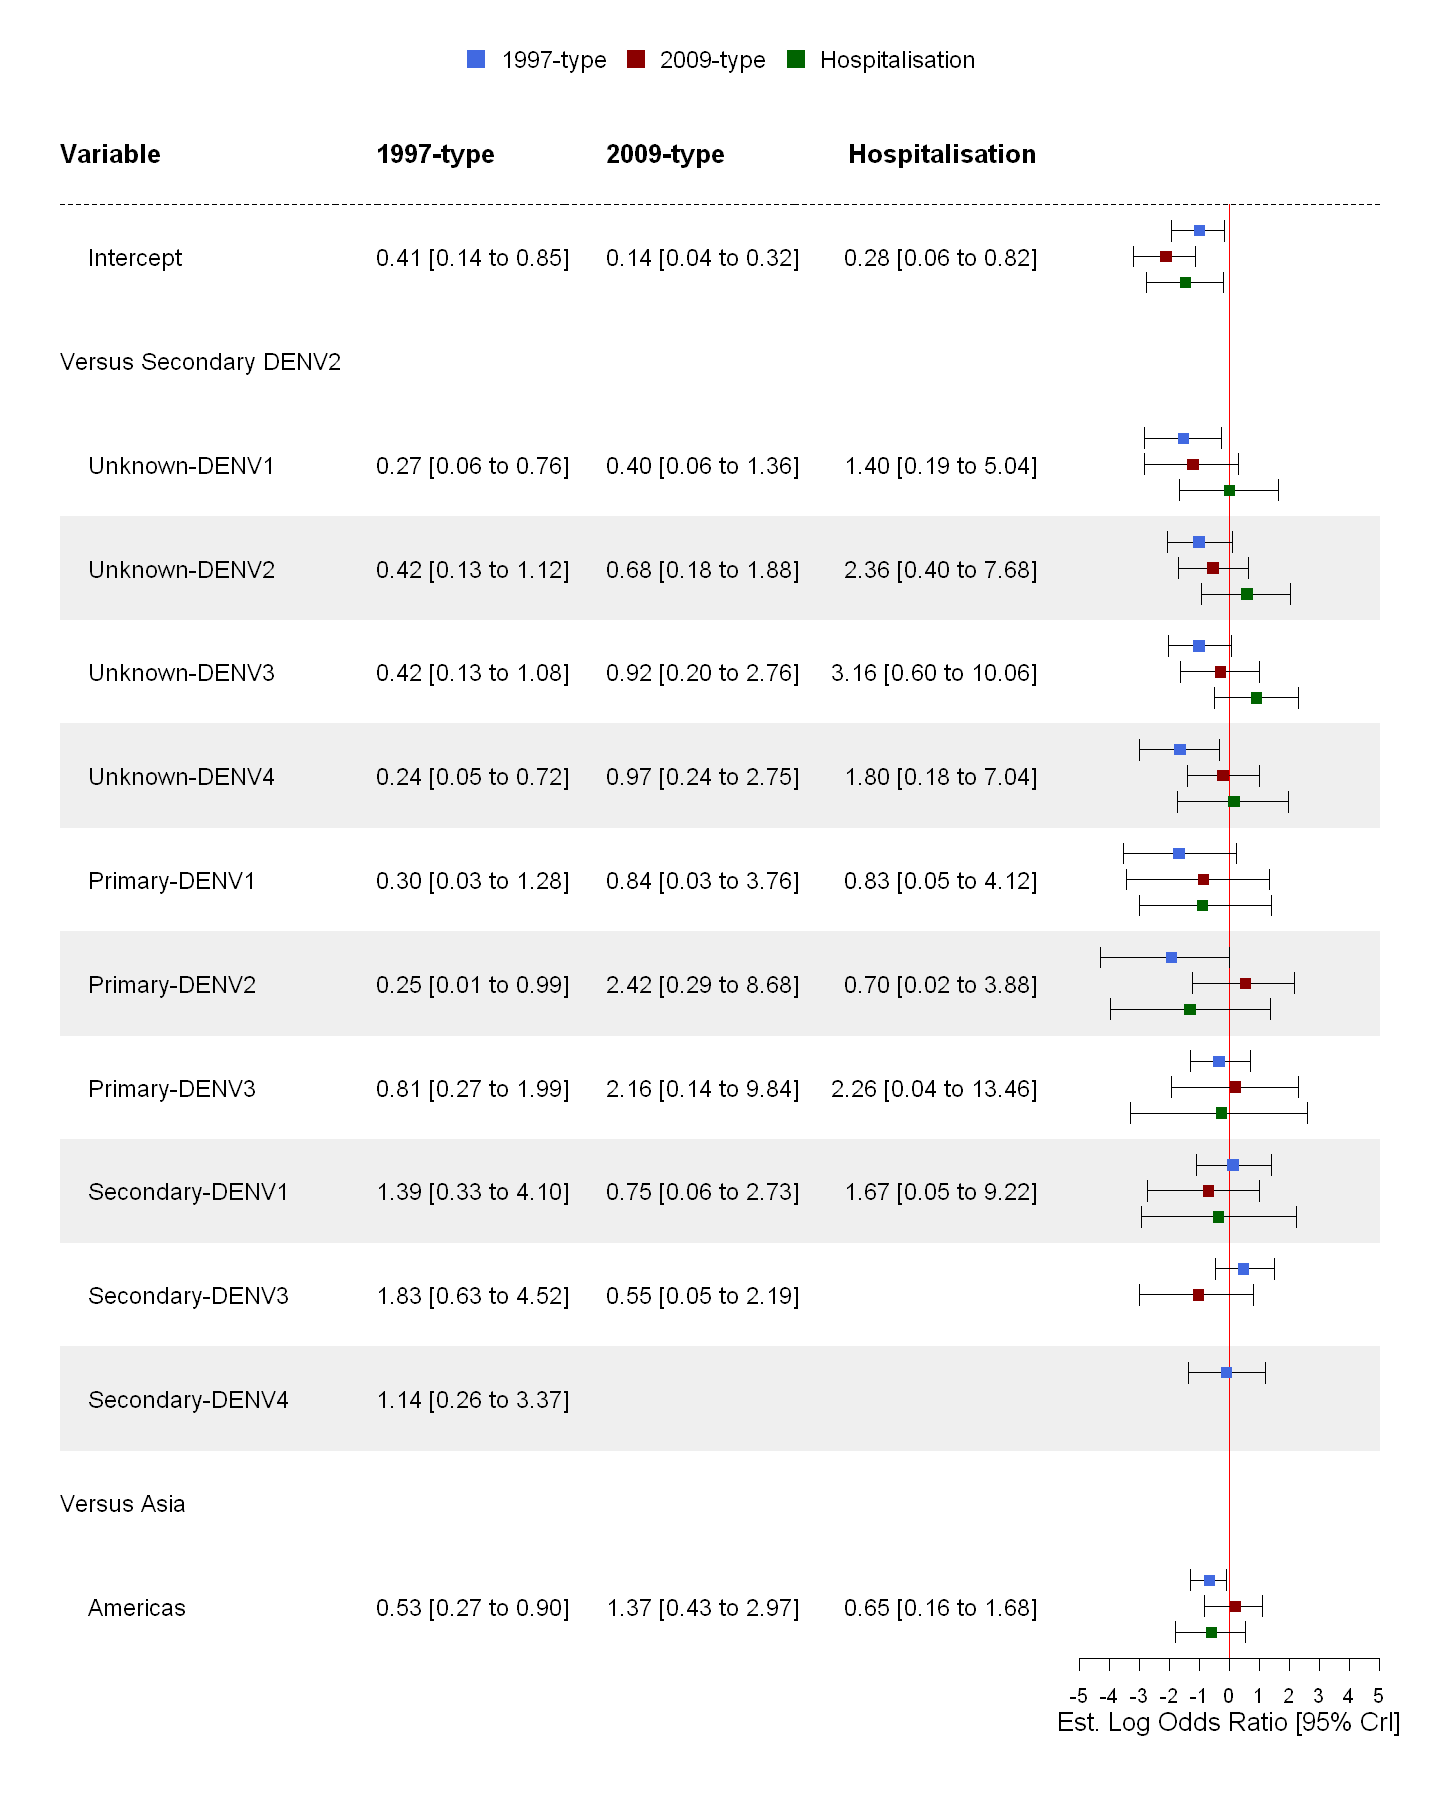

In [18]:
group_mean  = as.matrix(log_or_vis_alt_df[, c("PointEst_1997type", "PointEst_2009type", "PointEst_hospitalisation")])
group_lower = as.matrix(log_or_vis_alt_df[, c("Lower_1997type", "Lower_2009type", "Lower_hospitalisation")])
group_upper = as.matrix(log_or_vis_alt_df[, c("Upper_1997type", "Upper_2009type", "Upper_hospitalisation")])                   
axis_lim = 5
options(repr.plot.width = 12, repr.plot.height = 15)
or_vis_plot = or_vis_alt_df %>% select(Label, DispVal_1997type, DispVal_2009type, DispVal_hospitalisation) %>% 
     forestplot(labeltext = c(Label, DispVal_1997type, DispVal_2009type, DispVal_hospitalisation),  
                mean = group_mean, lower = group_lower, upper = group_upper, clip = c(-axis_lim, axis_lim), 
                xticks = seq(-axis_lim, axis_lim, by = 1), ci.vertices = TRUE, boxsize = 0.1, xlab = "Est. Log Odds Ratio [95% CrI]",
                align = c("l", "l", "l", "r"), graphwidth = unit(2.5, "in"), zero = 0,
                legend = c("1997-type", "2009-type", "Hospitalisation")
              ) |>
    fp_add_lines(h_2 = gpar(lty = 2)) |>
    fp_set_style(box = c("royalblue", "darkred", "darkgreen"), zero = "red", line = gpar(col = "black"),
                txt_gp = fpTxtGp(cex =1.2, legend = gpar(cex = 1.2), xlab = gpar(cex = 1.3), ticks = gpar(cex = 1))) |>
    fp_add_header(
                    Label = "Variable",
                    DispVal_1997type = "1997-type", 
                    DispVal_2009type = "2009-type", 
                    DispVal_hospitalisation = "Hospitalisation") |>
    
    fp_set_zebra_style("#EFEFEF")

#save_plot(or_vis_plot, file.path(visuals_output_dir, paste0("OR_Group_Plot.png")), 12, 15, "in", 600)
save_plot_all_formats(or_vis_plot, visuals_output_dir, "OR_Group_Plot", 12, 15, "in", 600)
or_vis_plot

In [19]:
# df <- tibble::tibble(
#   Label = paste("Outcome", 1:10),
#   PE_1 = runif(10, 0.8, 1.5),  LB_1 = PE_1 - runif(10, 0.1, 0.3), UB_1 = PE_1 + runif(10, 0.1, 0.3),
#   PE_2 = runif(10, 0.9, 1.6),  LB_2 = PE_2 - runif(10, 0.1, 0.3), UB_2 = PE_2 + runif(10, 0.1, 0.3),
#   PE_3 = runif(10, 1.0, 1.7),  LB_3 = PE_3 - runif(10, 0.1, 0.3), UB_3 = PE_3 + runif(10, 0.1, 0.3)
# )
# mean  <- as.matrix(df[, c("PE_1", "PE_2", "PE_3")])
# lower <- as.matrix(df[, c("LB_1", "LB_2", "LB_3")])
# upper <- as.matrix(df[, c("UB_1", "UB_2", "UB_3")])
# tabletext <- cbind(
#   df$Label,
#   sprintf("%.2f", df$PE_1),
#   sprintf("%.2f", df$PE_2),
#   sprintf("%.2f", df$PE_3)
# )

# colnames(tabletext) <- NULL  # Optional: remove column names

# # Colors for the 3 groups
# colors <- forestplot::fpColors(
#   box  = c("blue", "green", "red"),
#   lines = c("blue", "green", "red")
# )

# # Labels for the legend
# legend_labels <- c("Group 1", "Group 2", "Group 3")

# # Plot
# forestplot(
#   labeltext = tabletext,
#   mean = mean,
#   lower = lower,
#   upper = upper,
#   is.summary = rep(FALSE, nrow(mean)),
#   xlab = "Effect Size",
#   col = colors,
#   boxsize = 0.15,
#   legend = legend_labels,
#   legend_args = forestplot::fpLegend(pos = list(x = 0.9, y = 0.9)),
#   txt_gp = forestplot::fpTxtGp(label = gpar(fontsize = 10),
#                                ticks = gpar(fontsize = 9),
#                                xlab = gpar(fontsize = 11))
# )


## Versus Vaccine Trial Data
Here, we compare the pooled probability of hospitalisation to the values from the TAK-003 clinical trials.

In [22]:
vacc_dir = file.path(base_dir, "Vaccine Trial Data")

In [23]:
vacc_data_m57_sl = read_excel(file.path(vacc_dir, "Month57DataSriLanka.xlsx"))
vacc_data_m57_sl = vacc_data_m57_sl %>% mutate(Scenario = paste0(Serotype, " ", Scope, " (Month 57)"), SET = "Month 57", TYPE = "DATA")
vacc_data_m57_sl_bin = binconf(x = vacc_data_m57_sl$Hospitalised, n = vacc_data_m57_sl$VCD)
vacc_data_m57_sl = vacc_data_m57_sl %>% cbind(vacc_data_m57_sl_bin) 
vacc_data_m57_sl = vacc_data_m57_sl %>% select(-Scope) %>% rename(Cases = VCD, Severe = Hospitalised)
vacc_data_m57_sl

,Serotype,Cases,Severe,Scenario,SET,TYPE,PointEst,Lower,Upper
,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
X,DENV1,230,38,DENV1 All (Month 57),Month 57,DATA,0.1652174,0.12280096,0.2186332
X.1,DENV2,193,82,DENV2 All (Month 57),Month 57,DATA,0.4248705,0.35726517,0.4954081
X.2,DENV3,113,18,DENV3 All (Month 57),Month 57,DATA,0.1592920,0.10320049,0.2377869
X.3,DENV4,23,4,DENV4 All (Month 57),Month 57,DATA,0.1739130,0.06978654,0.3713765
X.4,DENV1,220,34,DENV1 Exc. Sri Lanka (Month 57),Month 57,DATA,0.1545455,0.11275091,0.2081970
X.5,DENV2,106,21,DENV2 Exc. Sri Lanka (Month 57),Month 57,DATA,0.1981132,0.13338894,0.2839531
X.6,DENV3,108,14,DENV3 Exc. Sri Lanka (Month 57),Month 57,DATA,0.1296296,0.07881271,0.2058890
X.7,DENV4,22,3,DENV4 Exc. Sri Lanka (Month 57),Month 57,DATA,0.1363636,0.04749004,0.3333499
X.8,DENV1,10,4,DENV1 Sri Lanka Only (Month 57),Month 57,DATA,0.4000000,0.16818033,0.6873262


In [24]:
pooled_ests = merged_forest_df %>% filter(SevClass == "hospitalisation") %>% #We are comparing trial data only to the pooled estimates where Prior Exposure is unknown
    separate(Scenario, sep = "-", into = c("Region", "PriorExposure", "Serotype"), remove = FALSE) %>%     
    filter(PriorExposure == "Unknown") %>% select(Serotype, N, Severe, Scenario, PointEst, Lower, Upper) %>% 
    rename(Cases = N) %>% mutate(SET = "POOLED", TYPE = "MODEL")

In [25]:
vacc_comp = rbind(pooled_ests, vacc_data_m57_sl) %>% arrange(Serotype, SET)

serotype_names = vacc_comp$Serotype %>% unique

add_serotype_headers = function(curr_sero){
    curr_data = vacc_comp %>% filter(Serotype == curr_sero)
    curr_data = curr_data %>% mutate(PointEstDisp = round(PointEst * 100, 2), LowerDisp = round(Lower * 100, 2), UpperDisp = round(Upper * 100, 2)) %>% 
                mutate(DispText = sprintf("%.2f%% [%.2f%% to %.2f%%]", PointEst * 100, Lower * 100, Upper * 100)) %>% select(-c(PointEstDisp, LowerDisp, UpperDisp))
    curr_header = data.frame(Serotype = curr_sero, Cases = "", Severe = "", PointEst = NaN, Lower = NaN, Upper = NaN, Scenario = curr_sero, TYPE = "HEADER", SET = "HEADER", DispText = "")
    curr_data = curr_header %>% rbind(curr_data) %>% mutate(Scenario = ifelse(TYPE != "HEADER", paste0("     ", Scenario), Scenario))
    return(curr_data)
}
vacc_comp_vis_df = do.call(rbind, lapply(serotype_names, add_serotype_headers))
vacc_comp_vis_df = vacc_comp_vis_df %>% mutate(Summ = SET == "POOLED")
vacc_comp_vis_df

,Serotype,Cases,Severe,PointEst,Lower,Upper,Scenario,TYPE,SET,DispText,Summ
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<lgl>
1,DENV1,,,NaN,NaN,NaN,DENV1,HEADER,HEADER,,FALSE
X,DENV1,230,38,0.1652174,0.12280096,0.2186332,DENV1 All (Month 57),DATA,Month 57,16.52% [12.28% to 21.86%],FALSE
X.4,DENV1,220,34,0.1545455,0.11275091,0.2081970,DENV1 Exc. Sri Lanka (Month 57),DATA,Month 57,15.45% [11.28% to 20.82%],FALSE
X.8,DENV1,10,4,0.4000000,0.16818033,0.6873262,DENV1 Sri Lanka Only (Month 57),DATA,Month 57,40.00% [16.82% to 68.73%],FALSE
11,DENV1,24909,7496,0.1270033,0.03368420,0.3368358,Americas-Unknown-DENV1,MODEL,POOLED,12.70% [3.37% to 33.68%],TRUE
5,DENV1,551,182,0.2017821,0.05613785,0.4131982,Asia-Unknown-DENV1,MODEL,POOLED,20.18% [5.61% to 41.32%],TRUE
12,DENV2,,,NaN,NaN,NaN,DENV2,HEADER,HEADER,,FALSE
X.1,DENV2,193,82,0.4248705,0.35726517,0.4954081,DENV2 All (Month 57),DATA,Month 57,42.49% [35.73% to 49.54%],FALSE
X.5,DENV2,106,21,0.1981132,0.13338894,0.2839531,DENV2 Exc. Sri Lanka (Month 57),DATA,Month 57,19.81% [13.34% to 28.40%],FALSE


pdf 
  2

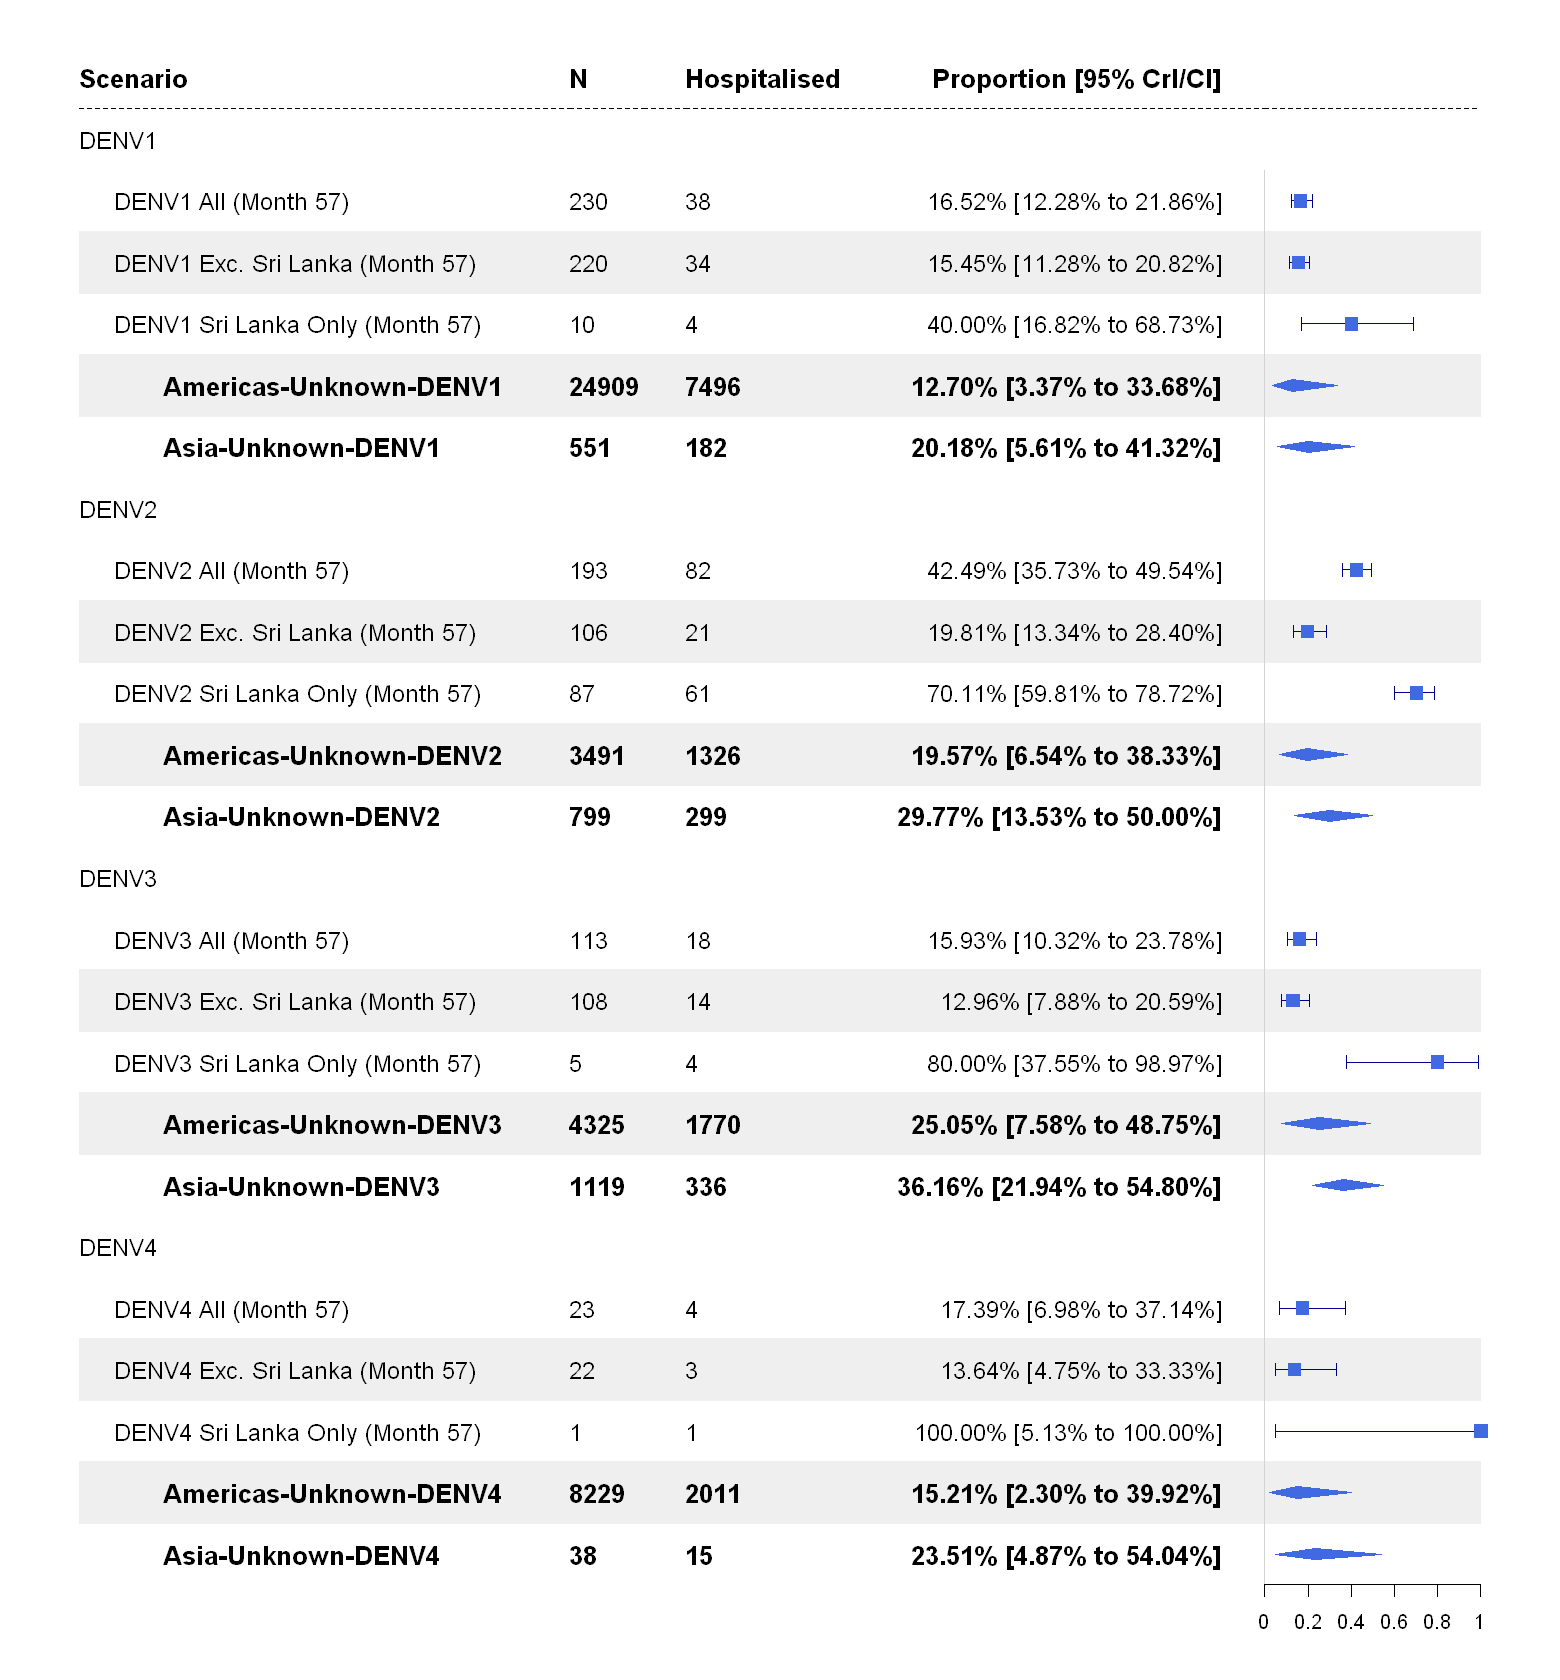

In [26]:
options(repr.plot.width = 13, repr.plot.height = 14)
vacc_comp_plot = vacc_comp_vis_df %>% 
     forestplot(labeltext = c(Scenario, Cases, Severe, DispText), is.summary = Summ, 
                mean = PointEst, lower = Lower, upper = Upper,
                xticks = seq(0, 1, by = 0.2), ci.vertices = TRUE, boxsize = 0.2,
                align = c("l", "l", "l", "r", "r", "l"), graphwidth = unit(1.8, "in"), 
              ) |>
    fp_add_lines(h_2 = gpar(lty = 2)) |>
    fp_set_style(box = "royalblue", line = gpar(col = "darkblue"), summary = "royalblue",
                txt_gp = fpTxtGp(cex =1.2, ticks = gpar(cex = 1))) |>
    fp_add_header(
                    Scenario = "Scenario",
                    Cases = "N", 
                    Severe = "Hospitalised", 
                    DispText = "Proportion [95% CrI/CI]") |>
    fp_set_zebra_style("#EFEFEF")

#save_plot(vacc_comp_plot, file.path(visuals_output_dir, paste0("Vacc Placebo Comp.png")), 13, 14, "in", 600)
save_plot_all_formats(vacc_comp_plot, visuals_output_dir, "Vacc Placebo Comp", 13, 14, "in", 600)
vacc_comp_plot

# Results Per Region and Country

In [27]:
index_df = read_excel(file.path(index_dir, "ReviewIndex_Final.xlsx"), sheet = "Main")


include_df = index_df %>% filter(FinalDecision %in% c("Include"))

#If the CovidenceID is blank, use the CovidenceID_JanUpdate value (the JanUpdate IDs are new ones from the updated Covidence review we made)
include_df = include_df %>% mutate(CovidenceID = ifelse(is.na(CovidenceID), CovidenceID_JanUpdate, CovidenceID))

#Lookup table for the country that each study is in
country_mapper = include_df %>% select(CovidenceID, Country) %>% distinct

#Get the outcome data from the model input files
outcomes_1997 = model_inputs[[1]]$outcome_df %>% mutate(SeveritySystem = "1997-type")
outcomes_2009 = model_inputs[[2]]$outcome_df %>% mutate(SeveritySystem = "2009-type")
outcomes_hosp = model_inputs[[3]]$outcome_df %>% mutate(SeveritySystem = "Hospitalisation")
all_outcome_dfs = rbind(outcomes_1997, outcomes_2009, outcomes_hosp) %>% left_join(country_mapper, by = "CovidenceID")

In [28]:
#Create a DataFrame that will serve as the basis of visualisations
to_vis = all_outcome_dfs %>% select(CovidenceID, SeveritySystem, Region, Country) %>% distinct 

#Find all studies with more than 1 country and split them into separate rows
multi_country = to_vis %>% filter(str_detect(Country, ";")) %>% separate(Country, sep = ";", into = c("Country1", "Country2")) %>% 
        pivot_longer(c(Country1, Country2), values_to = "Country") %>% select(-name) %>% mutate(Country = trimws(Country))

#Remove those with multiple countries and append the split row version
to_vis = to_vis %>% filter(!str_detect(Country, ";")) %>% rbind(multi_country)

to_vis = to_vis %>% group_by(Region, Country, SeveritySystem) %>% 
            summarise(NumStudies = n_distinct(CovidenceID))

`summarise()` has grouped output by 'Region', 'Country'. You can override using
the `.groups` argument.


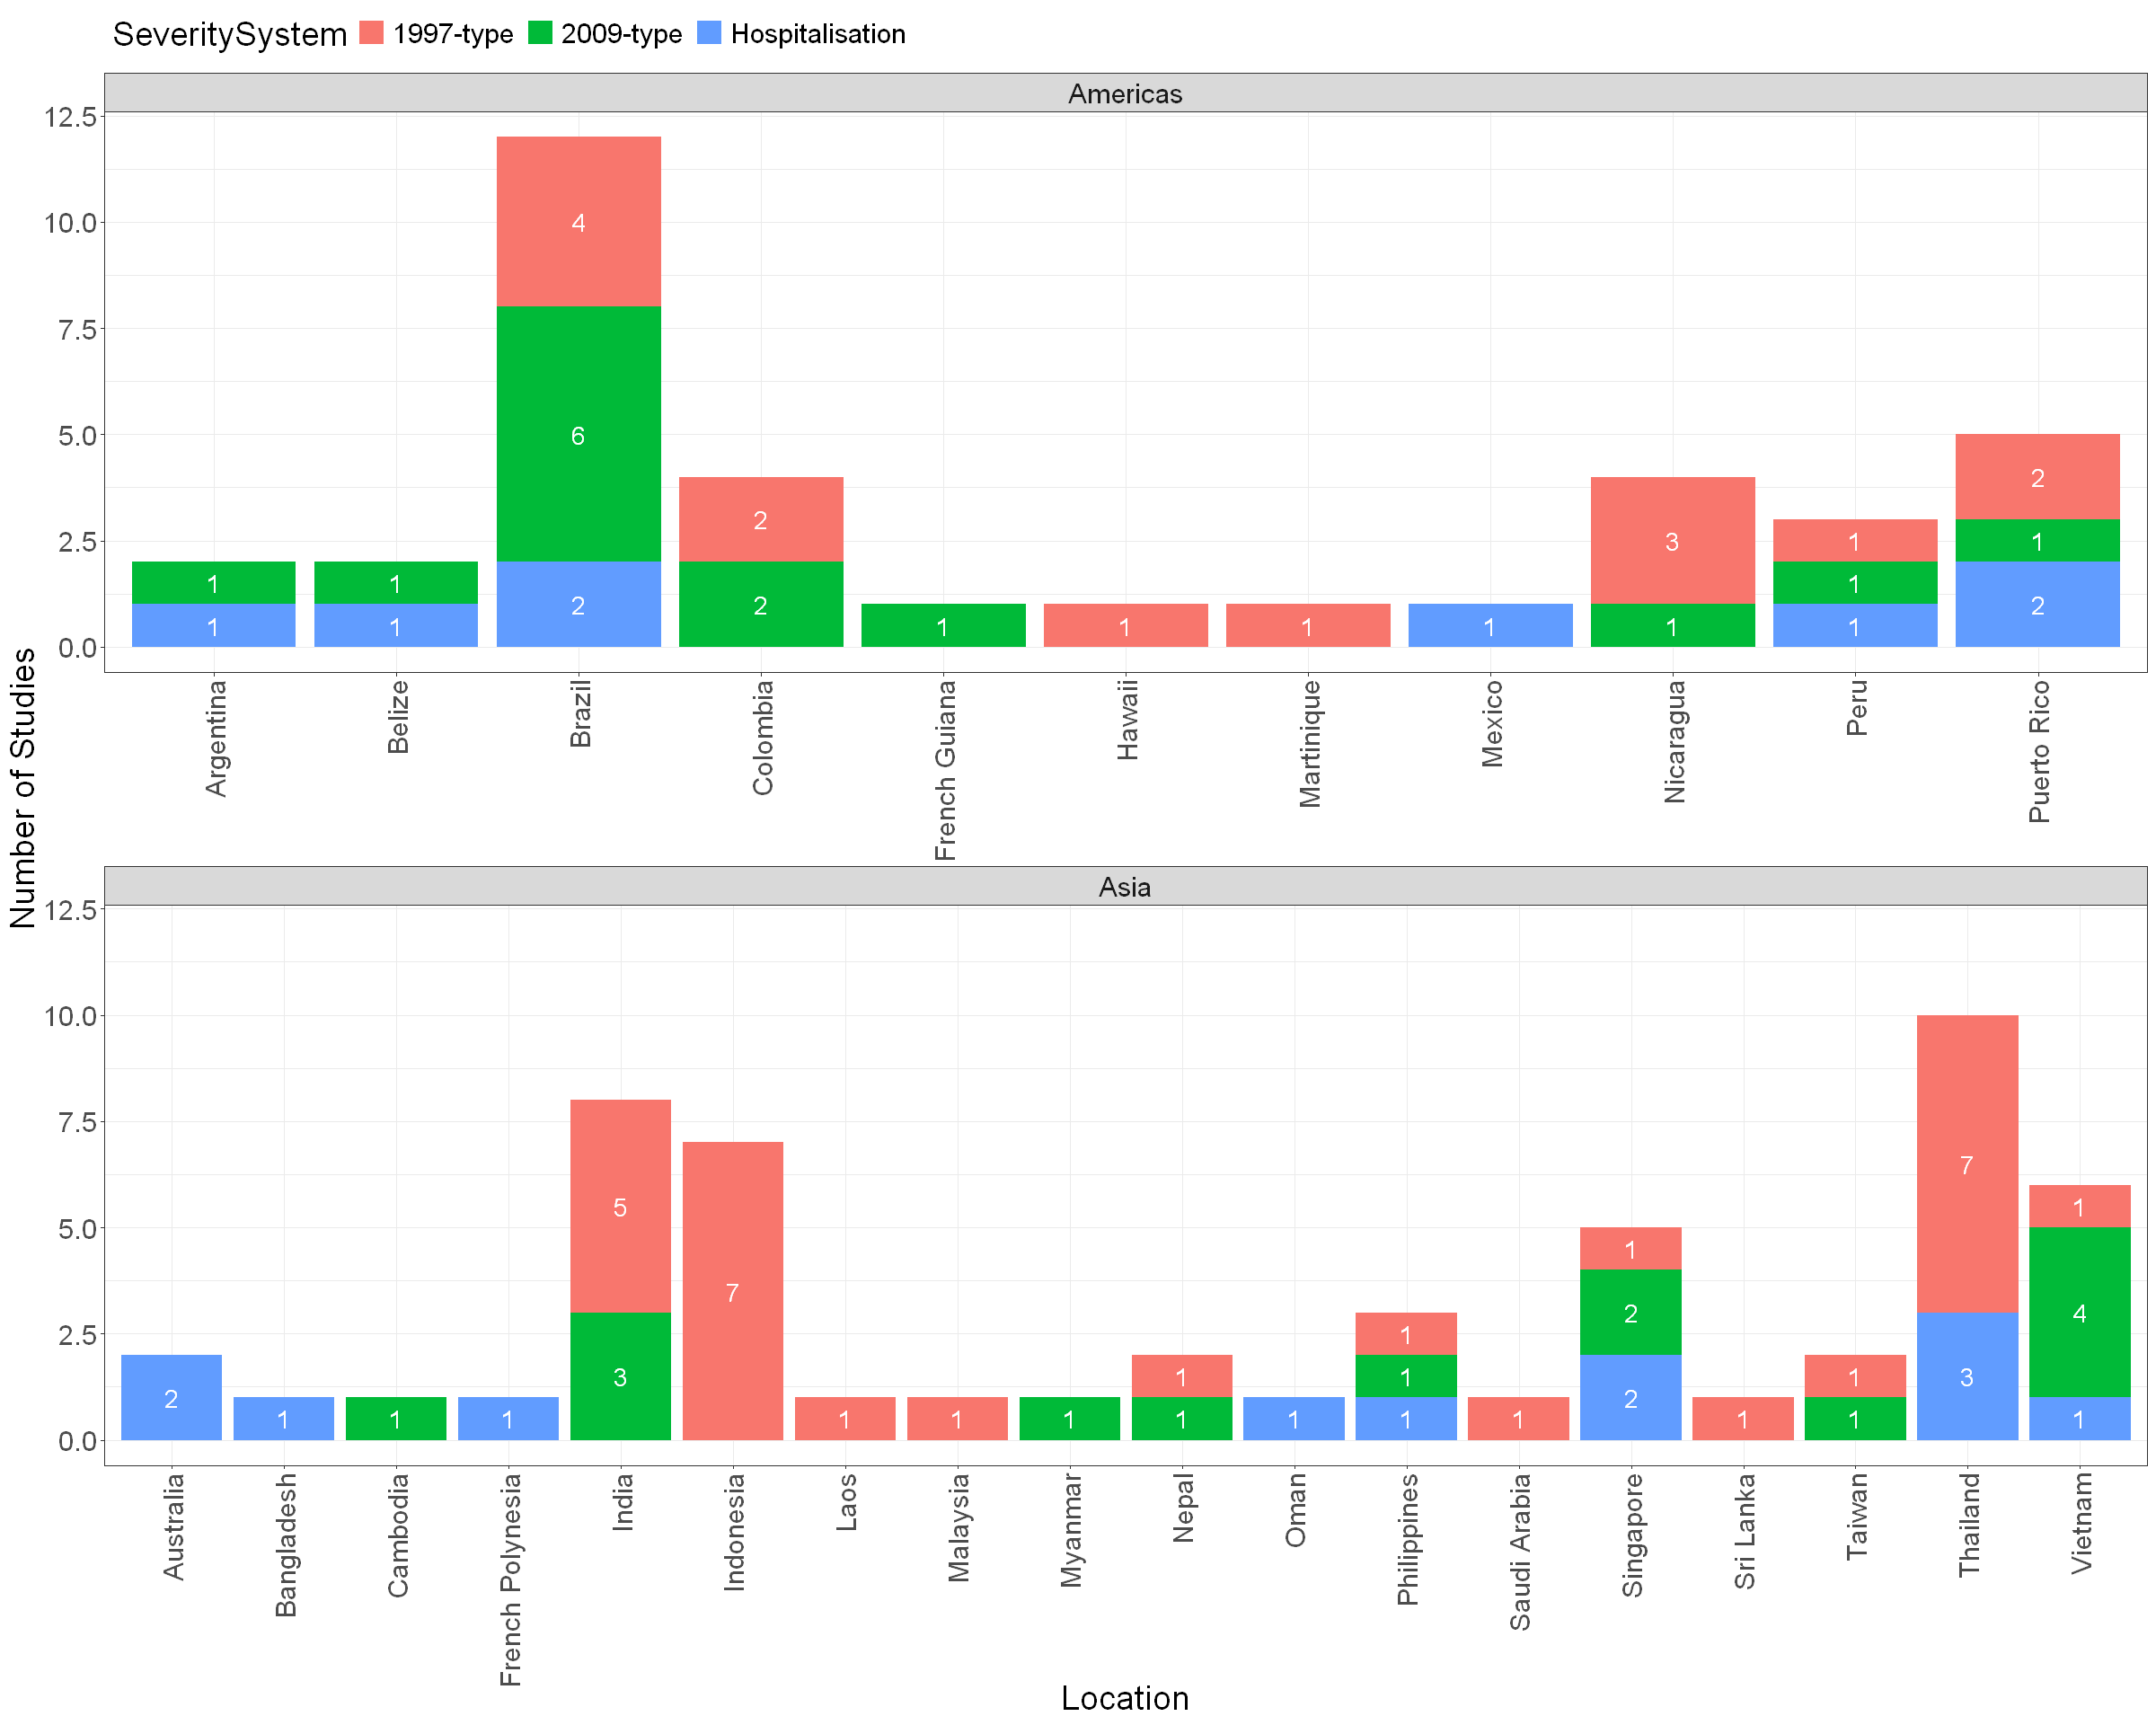

In [29]:
options(repr.plot.width = 20, repr.plot.height = 16)
to_vis %>% arrange(Country) %>% 
    ggplot(aes(x = Country, y = NumStudies, fill = SeveritySystem, label = NumStudies)) + 
        geom_bar(position = "stack", stat = "identity") +
        geom_text(size = 6, position = position_stack(vjust = 0.5), colour = "white") +
        facet_wrap(~Region, ncol = 1, scale = "free_x") +
        xlab("Location") + ylab("Number of Studies") +
        theme(text = element_text(size = 23),
              axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1),
              legend.justification = "left", legend.position = "top")
ggsave(file.path(visuals_output_dir, "png", "StudyCountsSummary.png"), width = 20, height = 16, unit = "in")
ggsave(file.path(visuals_output_dir, "eps", "StudyCountsSummary.eps"), width = 20, height = 16, unit = "in")
ggsave(file.path(visuals_output_dir, "pdf", "StudyCountsSummary.pdf"), width = 20, height = 16, unit = "in")